In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Cargando el dataset en la nube de Google...")
# En Colab la ruta es directa porque lo subiste al panel de archivos
# Cambia 'covtype.csv.zip' por 'covtype.csv'
df = pd.read_csv('covtype.csv')

filas, columnas = df.shape
print(f"✅ ¡Dataset cargado con éxito en Colab!")
print(f"📊 Filas: {filas:,} | 📋 Columnas: {columnas}")

df.head()

Cargando el dataset en la nube de Google...
✅ ¡Dataset cargado con éxito en Colab!
📊 Filas: 581,012 | 📋 Columnas: 55


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
# 1. Tomar una muestra representativa y fija para que sea reproducible
df_sample = df.sample(n=20000, random_state=42).reset_index(drop=True)
print(f"Tamaño de la muestra para gráficos: {df_sample.shape[0]} filas.\n")

# 2. Verificar valores nulos en el dataset
null_counts = df_sample.isnull().sum().sum()
print(f"Total de valores nulos detectados: {null_counts}")
if null_counts == 0:
    print("Nota para el informe: El dataset no presenta valores nulos de fábrica, por lo que justificaremos el preprocesamiento mediante el escalado de características y codificación de variables.")

Tamaño de la muestra para gráficos: 20000 filas.

Total de valores nulos detectados: 0
Nota para el informe: El dataset no presenta valores nulos de fábrica, por lo que justificaremos el preprocesamiento mediante el escalado de características y codificación de variables.


In [ ]:
# Seleccionar las primeras 10 columnas numéricas continuas
columnas_numericas = df_sample.columns[:10]

# Generar la tabla de estadísticas descriptivas
print("📊 Estadísticas Descriptivas de las Variables Topográficas:")
df_sample[columnas_numericas].describe().T

📊 Estadísticas Descriptivas de las Variables Topográficas:


,count,mean,std,min,25%,50%,75%,max
Elevation,20000.0,2961.23935,276.777910,1883.0,2812.00,2997.5,3164.0,3845.0
Aspect,20000.0,155.84660,112.073340,0.0,58.00,127.0,261.0,360.0
Slope,20000.0,14.11595,7.497707,0.0,9.00,13.0,18.0,62.0
Horizontal_Distance_To_Hydrology,20000.0,271.09725,212.322296,0.0,108.00,218.0,390.0,1361.0
Vertical_Distance_To_Hydrology,20000.0,46.75155,58.997172,-173.0,7.00,30.0,69.0,597.0
Horizontal_Distance_To_Roadways,20000.0,2342.09565,1556.705205,0.0,1099.00,2002.0,3291.0,7078.0
Hillshade_9am,20000.0,212.12900,26.863874,0.0,198.00,218.0,231.0,254.0
Hillshade_Noon,20000.0,223.34090,19.712352,0.0,213.00,226.0,237.0,254.0
Hillshade_3pm,20000.0,142.55635,38.386405,0.0,119.00,143.0,169.0,253.0
Horizontal_Distance_To_Fire_Points,20000.0,1972.74040,1316.955126,0.0,1019.75,1706.0,2547.0,7028.0


/tmp/ipykernel_1213/868729983.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cover_Type', data=df_sample, palette='magma')


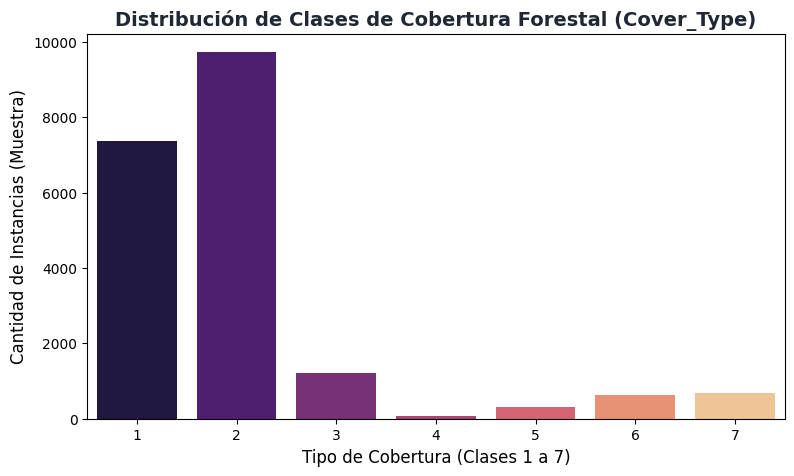

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo visual (paleta Magma/Morados profesionales)
plt.figure(figsize=(9, 5))
sns.countplot(x='Cover_Type', data=df_sample, palette='magma')

# Añadir títulos y etiquetas
plt.title('Distribución de Clases de Cobertura Forestal (Cover_Type)', fontsize=14, fontweight='bold', color='#1f2833')
plt.xlabel('Tipo de Cobertura (Clases 1 a 7)', fontsize=12)
plt.ylabel('Cantidad de Instancias (Muestra)', fontsize=12)

# Mostrar el gráfico
plt.show()

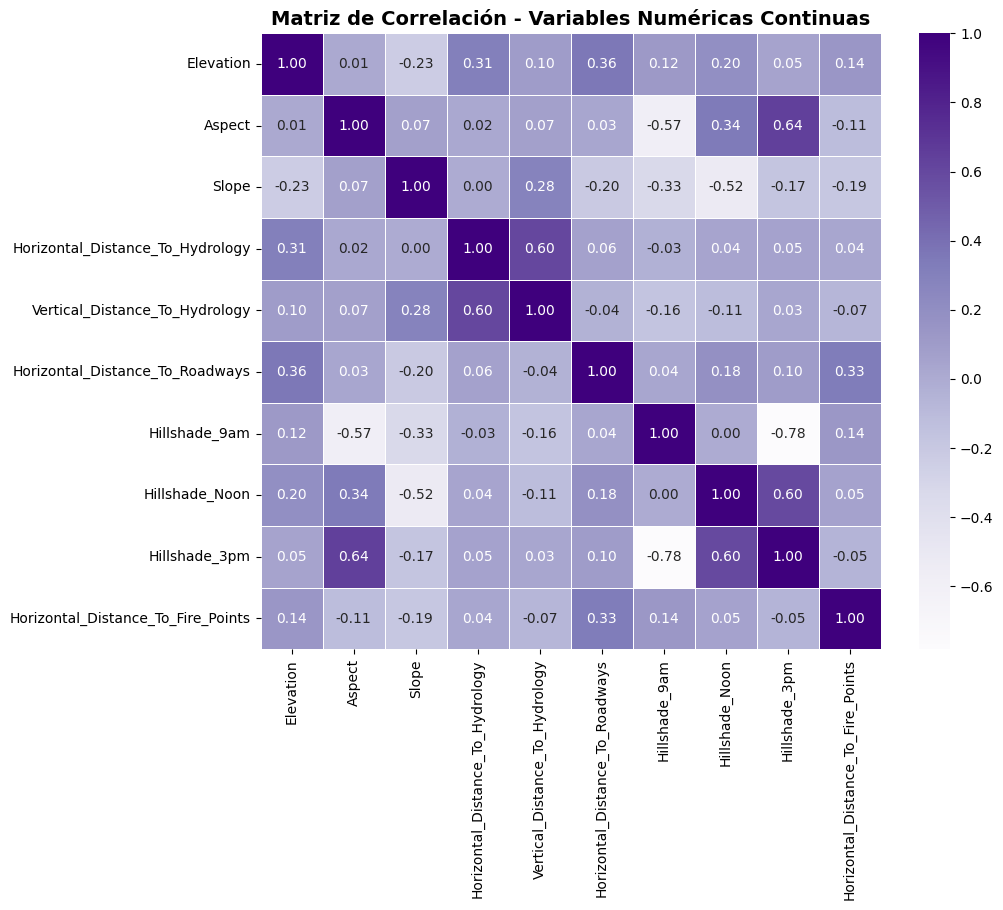

In [ ]:
# Calcular la matriz de correlación de las variables numéricas
corr_matrix = df_sample[columnas_numericas].corr()

# Dibujar el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Purples', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas Continuas', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_1213/3899587114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cover_Type', y='Elevation', data=df_sample, palette='Purples')


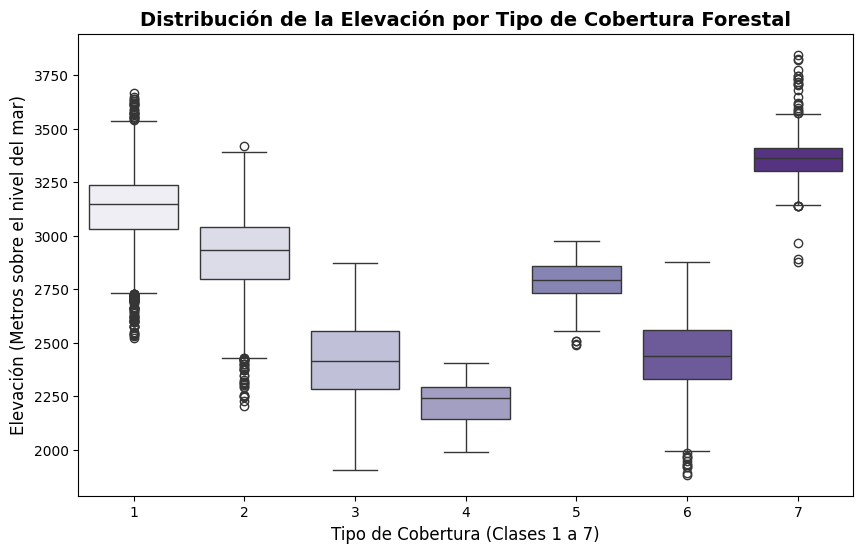

In [ ]:
# Gráfico de cajas para ver la distribución de la Elevación por cada Tipo de Cobertura
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cover_Type', y='Elevation', data=df_sample, palette='Purples')

# Personalización técnica
plt.title('Distribución de la Elevación por Tipo de Cobertura Forestal', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Cobertura (Clases 1 a 7)', fontsize=12)
plt.ylabel('Elevación (Metros sobre el nivel del mar)', fontsize=12)
plt.show()

# **02_preprocessing**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Usamos la muestra aleatoria balanceada de 20,000 filas que creamos en el EDA
X = df_sample.drop(columns=['Cover_Type'])

# Ajustamos las etiquetas: de (1 a 7) pasamos a (0 a 6)
y = df_sample['Cover_Type'] - 1

print(f"Forma de las características (X): {X.shape}")
print(f"Clases únicas ajustadas en la variable objetivo (y): {np.unique(y)}")

Forma de las características (X): (20000, 54)
Clases únicas ajustadas en la variable objetivo (y): [0 1 2 3 4 5 6]


In [ ]:
# Dividimos: 80% para entrenar el modelo y 20% para evaluar los resultados
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # <-- El secreto para manejar el desbalance de datos
    random_state=42      # Semilla para que a Sebastián le dé igual
)

print(f"Datos de entrenamiento (Train): {X_train.shape[0]} filas")
print(f"Datos de prueba (Test): {X_test.shape[0]} filas")

Datos de entrenamiento (Train): 16000 filas
Datos de prueba (Test): 4000 filas


In [ ]:
# 1. Identificar las primeras 10 columnas que son las numéricas continuas
columnas_num = list(X.columns[:10])
print(f"Columnas a escalar: {columnas_num}")

# 2. Inicializar el escalador estándar
scaler = StandardScaler()

# 3. Crear copias para no alterar los dataframes originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. Ajustar y transformar el conjunto de entrenamiento, y solo transformar el de prueba
X_train_scaled[columnas_num] = scaler.fit_transform(X_train[columnas_num])
X_test_scaled[columnas_num] = scaler.transform(X_test[columnas_num])

print("\n✅ ¡Escalado completado con éxito!")
# Mostrar un ejemplo de cómo quedaron los datos transformados
X_train_scaled[columnas_num].head(3)

Columnas a escalar: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

✅ ¡Escalado completado con éxito!


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
13676,0.888179,1.293438,-0.146744,-1.133463,-0.694919,1.226731,-1.120643,0.547144,1.285527,-0.448321
17632,0.812411,-1.266017,-1.346966,-0.874710,-0.780512,-0.599497,0.143344,0.394535,0.273376,-0.973497
10765,0.022261,-0.748776,-1.213608,0.301441,-1.465254,0.897148,0.515105,0.343666,-0.115912,2.849631


# **03_model_main**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Instanciar el modelo de Regresión Softmax
print("🏋️ Entrenando el modelo Softmax Regression...")
softmax_model = LogisticRegression(
    multi_class='multinomial',   # Obliga a usar la función Softmax multiclase
    solver='lbfgs',              # Algoritmo de optimización quasi-Newton eficiente
    C=1.0,                       # Fuerza de regularización inversa (L2 por defecto)
    max_iter=1000,               # Asegura la convergencia del gradiente
    random_state=42              # Semilla de reproducibilidad
)

# 2. Ajustar el modelo con los datos escalados de entrenamiento
softmax_model.fit(X_train_scaled, y_train)
print("✅ ¡Entrenamiento completado!")

# 3. Realizar predicciones sobre el conjunto de prueba (examen final)
y_pred_softmax = softmax_model.predict(X_test_scaled)

🏋️ Entrenando el modelo Softmax Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ ¡Entrenamiento completado!


In [ ]:
# Generar el reporte de métricas detallado
print("📊 REPORTE DE CLASIFICACIÓN (REGRESIÓN SOFTMAX):\n")
print(classification_report(y_test, y_pred_softmax, target_names=[f"Clase {i+1}" for i in range(7)]))

# Guardar métricas globales para la comparación posterior
accuracy_softmax = accuracy_score(y_test, y_pred_softmax)
f1_softmax = f1_score(y_test, y_pred_softmax, average='weighted')

📊 REPORTE DE CLASIFICACIÓN (REGRESIÓN SOFTMAX):

              precision    recall  f1-score   support

     Clase 1       0.74      0.70      0.72      1473
     Clase 2       0.74      0.81      0.77      1945
     Clase 3       0.66      0.80      0.72       241
     Clase 4       0.80      0.47      0.59        17
     Clase 5       0.00      0.00      0.00        64
     Clase 6       0.40      0.25      0.31       125
     Clase 7       0.86      0.63      0.73       135

    accuracy                           0.73      4000
   macro avg       0.60      0.52      0.55      4000
weighted avg       0.72      0.73      0.72      4000



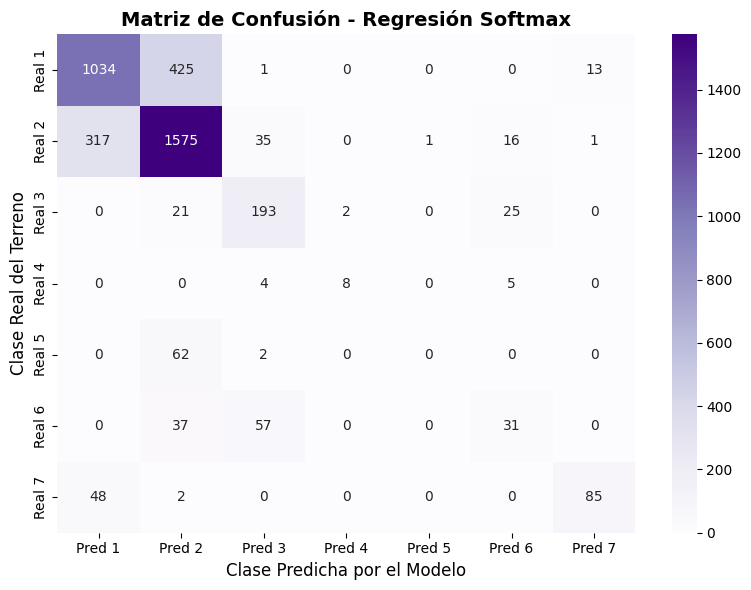

In [ ]:
# 1. Calcular la matriz de confusión
cm_softmax = confusion_matrix(y_test, y_pred_softmax)

# 2. Graficar con Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_softmax,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=[f"Pred {i+1}" for i in range(7)],
    yticklabels=[f"Real {i+1}" for i in range(7)]
)

plt.title('Matriz de Confusión - Regresión Softmax', fontsize=14, fontweight='bold')
plt.xlabel('Clase Predicha por el Modelo', fontsize=12)
plt.ylabel('Clase Real del Terreno', fontsize=12)
plt.tight_layout()
plt.show()

# **04_model_comparison**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("🌲 Entrenando el Modelo Comparativo: Random Forest Classifier...")

# 1. Instanciar el modelo con 150 árboles y profundidad controlada para evitar sobreajuste
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    random_state=42,
    n_jobs=-1          # Usa todos los núcleos del procesador de Google para ir a mil por hora
)

# 2. Entrenar (Con Random Forest podemos usar los datos escalados igual que en Softmax)
rf_model.fit(X_train_scaled, y_train)
print("✅ ¡Entrenamiento de Random Forest completado!")

# 3. Predecir
y_pred_rf = rf_model.predict(X_test_scaled)

# 4. Mostrar el nuevo reporte de clasificación
print("\n📊 REPORTE DE CLASIFICACIÓN (RANDOM FOREST):\n")
print(classification_report(y_test, y_pred_rf, target_names=[f"Clase {i+1}" for i in range(7)]))

🌲 Entrenando el Modelo Comparativo: Random Forest Classifier...
✅ ¡Entrenamiento de Random Forest completado!

📊 REPORTE DE CLASIFICACIÓN (RANDOM FOREST):

              precision    recall  f1-score   support

     Clase 1       0.80      0.75      0.77      1473
     Clase 2       0.78      0.87      0.82      1945
     Clase 3       0.75      0.85      0.80       241
     Clase 4       1.00      0.35      0.52        17
     Clase 5       0.80      0.12      0.22        64
     Clase 6       0.70      0.38      0.49       125
     Clase 7       0.96      0.69      0.80       135

    accuracy                           0.79      4000
   macro avg       0.83      0.57      0.63      4000
weighted avg       0.79      0.79      0.78      4000



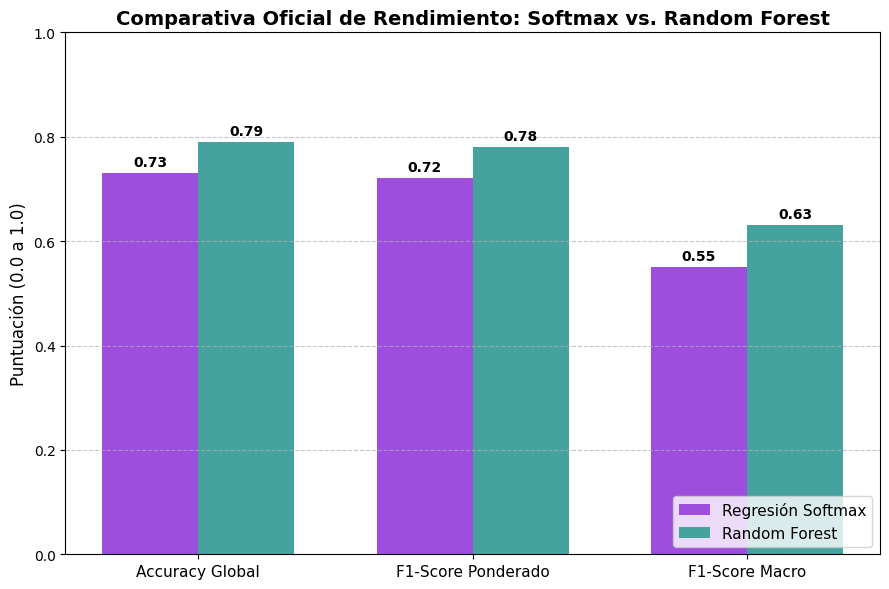

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos extraídos directamente de tus ejecuciones reales
metricas = ['Accuracy Global', 'F1-Score Ponderado', 'F1-Score Macro']
valores_softmax = [0.73, 0.72, 0.55]
valores_rf = [0.79, 0.78, 0.63]

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

# Barras con estilo elegante (Tonos oscuros/púrpuras)
rects1 = ax.bar(x - width/2, valores_softmax, width, label='Regresión Softmax', color='#9d4edd')
rects2 = ax.bar(x + width/2, valores_rf, width, label='Random Forest', color='#45a29e')

# Añadir etiquetas técnicas
ax.set_ylabel('Puntuación (0.0 a 1.0)', fontsize=12)
ax.set_title('Comparativa Oficial de Rendimiento: Softmax vs. Random Forest', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Función para poner el valor numérico arriba de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()